# TCS Stock Price Prediction using Random Forest

Predicting tomorrow's closing price of TCS (Tata Consultancy Services) using a Random Forest Regressor.

**Features:** Open, High, Low, Volume, Prev_Close, Price_Change, HL_Spread, OC_Spread, MA_5, MA_10

**Target:** Next day's Close price

In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import joblib
import warnings

warnings.filterwarnings('ignore')

## Download TCS Stock Data

In [10]:
df = yf.download('TCS.NS', start='2015-01-01')
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

print(f"Shape: {df.shape}")
df.head()

[*********************100%***********************]  1 of 1 completed

Shape: (2890, 5)


Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-01,970.330566,978.507009,968.596147,978.507009,366830
2015-01-02,983.252930,987.636581,972.255739,972.408177,925740
2015-01-05,968.310181,991.047946,962.363627,983.843549,1754242
2015-01-06,932.612183,964.060111,930.096311,964.060111,2423784
2015-01-07,921.595581,945.019498,917.688415,941.531675,2636332


In [16]:
df.tail(5)

Price,Open,High,Low,Volume,Close,Prev_Close,Price_Change,HL_Spread,OC_Spread,MA_5,MA_10,Target
Date,,,,,,,,,,,,
2026-09-02,2347.899902,2363.000000,2303.500000,2533005,2348.000000,2369.000000,0.100098,59.500000,0.100098,2341.339990,2315.700000,2320.100098
2026-09-03,2353.600098,2353.600098,2316.100098,1892786,2320.100098,2348.000000,-33.500000,37.500000,-33.500000,2355.680029,2317.910010,2304.000000
2026-09-04,2330.000000,2363.899902,2302.399902,2564322,2304.000000,2320.100098,-26.000000,61.500000,-26.000000,2348.080029,2318.110010,2270.000000
2026-09-07,2290.100098,2299.899902,2260.100098,2297551,2270.000000,2304.000000,-20.100098,39.799805,-20.100098,2322.220020,2316.700000,2255.500000
2026-09-08,2270.000000,2274.500000,2244.000000,2148114,2255.500000,2270.000000,-14.500000,30.500000,-14.500000,2299.520020,2312.630005,2208.000000


## Feature Engineering

In [11]:
df = df[['Open', 'High', 'Low', 'Volume', 'Close']].copy()
df['Prev_Close'] = df['Close'].shift(1)
df['Price_Change'] = df['Close'] - df['Open']
df['HL_Spread'] = df['High'] - df['Low']
df['OC_Spread'] = df['Close'] - df['Open']
df['MA_5'] = df['Close'].rolling(5).mean()
df['MA_10'] = df['Close'].rolling(10).mean()
df['Target'] = df['Close'].shift(-1)
df.dropna(inplace=True)

features = ['Open', 'High', 'Low', 'Volume', 'Prev_Close', 'Price_Change', 'HL_Spread', 'OC_Spread', 'MA_5', 'MA_10']
X = df[features]
y = df['Target']

print(f"Features shape: {X.shape}")

Features shape: (2880, 10)


## Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 2304
Test size: 576


## Train Random Forest Model

In [13]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Cross Validation & Evaluation

In [14]:
cv_scores = cross_val_score(model, X_train, y_train, cv=5)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R\u00b2 Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"Mean CV Score: {cv_scores.mean():.4f}")

R² Score: 0.9986
MAE: 25.0527
Mean CV Score: 0.9984


## Visualizations

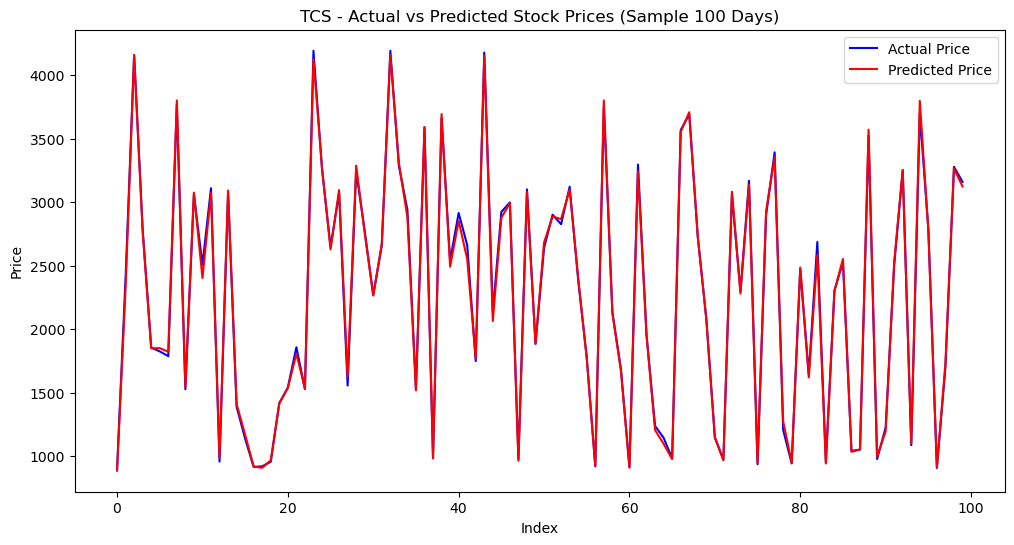

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:100], label='Actual Price', color='blue')
plt.plot(y_pred[:100], label='Predicted Price', color='red')
plt.title('TCS - Actual vs Predicted Stock Prices (Sample 100 Days)')
plt.xlabel('Index')
plt.ylabel('Price')
plt.legend()
plt.show()

## Save Model

In [8]:
joblib.dump(model, 'tcs_model.pkl')
print('Model saved as tcs_model.pkl')

Model saved as tcs_model.pkl
